# DNN: analysis with Keras of 2D data

# Keras Tuner
check https://keras.io/keras_tuner/getting_started/ or just pip install keras-tuner -q

install tensorflow


!pip install keras-tuner -q




pip install tensorflow


In [1]:
import numpy as np

from keras.models import Sequential
from keras.layers import Dense, Dropout
import keras

import matplotlib as mpl
import matplotlib.pyplot as plt
# default font
plt.rcParams['font.size'] = 13

from sklearn.preprocessing import StandardScaler

%run useful.py  # Commented out: File 'useful.py' not found.

# training/validation/test fractions
perc_train = 0.7
perc_valid = 0.15
perc_test = 0.15
#  check it sums to 1
assert abs(perc_train + perc_valid + perc_test - 1.0) < 1e-12

## Read data

(12000, 8)
8
[1.83918812 2.04560279 5.67725029 5.95544703 9.6451452  6.53177097
 7.48906638 6.53569871] 1
[7.47714809 9.61306736 0.08388298 1.06444377 2.98703714 6.56411183
 8.09812553 8.72175914] 0
[9.64647597 7.23685347 6.42475328 7.17453621 4.67599007 3.25584678
 4.39644606 7.29689083] 0
[9.94014586 6.76873712 7.90822518 1.70914258 0.26849276 8.00370244
 9.03722538 0.2467621 ] 0
[4.91747318 5.26255167 5.9636601  0.51957545 8.95089528 7.2826618
 8.18350011 5.00222753] 1
data: 12000
train: 8400
valid: 1800
test: 1800


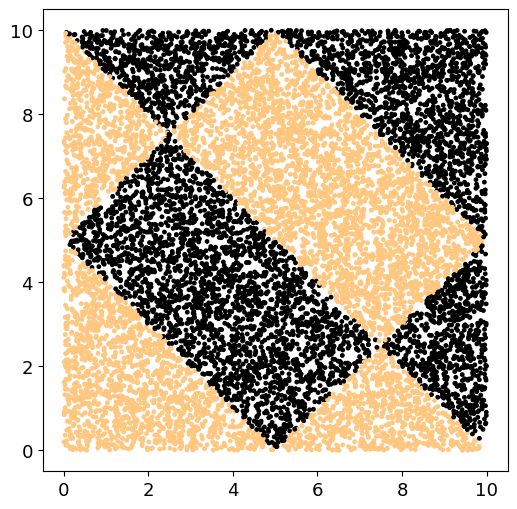

In [2]:
from useful import filename,plot_data

# Keras works with numpy arrays: just use them from the start

TYPE=3
# number of features per sample
L=8
# span of each component
B=10
x = np.loadtxt(filename("data",L,TYPE), delimiter=' ')
y = np.loadtxt(filename("labels",L,TYPE), delimiter=' ')
y = y.astype("int")
print(x.shape)
N = len(x)


# dim. of a sample
L = len(x[0])
print(L)

for i in range(5):
    print(x[i],y[i])

N_train = int(perc_train * N)
N_valid = int(perc_valid * N)
N_test = N - N_train - N_valid
print(f'data: {N}\ntrain: {N_train}\nvalid: {N_valid}\ntest: {N_test}')

plot_data(x,y)

## Split data and standardize (fit on train only)

In [3]:
def Standardize(x,m,s):
    """
    rescale each component using its mean and standard deviation
    x: data points (numpy array)
    m: mean values (numpy array)
    s: standard deviations (numpy array)
    return: rescaled data points (numpy array)
    """
    N = len(x)
    # assuming len(m)=len(s)=len(x[0])
    mm,ss = np.tile(m,(N,1)), np.tile(s,(N,1))
    return (x-mm)/ss

# split data into train/validation/test sets and check
(x_train, y_train) = (x[0:N_train],y[0:N_train])
(x_valid, y_valid) = (x[N_train:N_train+N_valid],y[N_train:N_train+N_valid])
(x_test, y_test) = (x[N_train+N_valid:],y[N_train+N_valid:])
print("Train:",len(x_train),"\t Validation:",len(x_valid),"\t Test:",len(x_test))


x_train_mean = np.mean(x_train, axis=0)
x_train_std = np.std(x_train, axis=0)
#print("train stats before rescaling:\nmean value=", x_train_mean, "\nstd. dev.=", x_train_std)

x_valid_mean = np.mean(x_valid, axis=0)
x_valid_std = np.std(x_valid, axis=0)
#print("validation stats before rescaling:\nmean value=", x_valid_mean, "\nstd. dev.=", x_valid_std)

x_test_mean = np.mean(x_test, axis=0)
x_test_std = np.std(x_test, axis=0)
#print("test stats before rescaling:\nmean value=", x_test_mean, "\nstd. dev.=", x_test_std)

x_train = Standardize(x_train, x_train_mean, x_train_std)
x_valid = Standardize(x_valid, x_valid_mean, x_valid_std)
x_test = Standardize(x_test, x_test_mean, x_test_std)
print("after rescaling (train):\nmean value=", x_train.mean(axis=0), "\nstd. dev.=", x_train.std(axis=0))

Train: 8400 	 Validation: 1800 	 Test: 1800
after rescaling (train):
mean value= [ 9.17572896e-16  1.18834043e-14 -1.95478554e-15 -3.53337069e-15
 -6.42594443e-15 -2.40365928e-15 -2.88332932e-15 -8.27623684e-15] 
std. dev.= [1. 1. 1. 1. 1. 1. 1. 1.]


## Define the model with Keras / Tensorflow

In [4]:
# reproducibility (?)
np.random.seed(12345)
import tensorflow.random as tf_r
tf_r.set_seed(12345)

# We use case 1
CASE=1

if CASE==1:
    model = Sequential()
    model.add(Dense(L,input_shape=(L,),activation='relu'))
    model.add(Dense(20,activation='relu'))
    model.add(Dropout(0.1))
    model.add(Dense(20,activation='relu'))
    model.add(Dropout(0.1))
    model.add(Dense(20,activation='relu'))
    model.add(Dropout(0.1))
    model.add(Dense(1,activation='sigmoid'))
    nepoch=200
# as case 1 but one layer shorter
if CASE==2:
    model = Sequential()
    model.add(Dense(L,input_shape=(L,),activation='relu'))
    model.add(Dense(40,activation='relu'))
    model.add(Dropout(0.1))
    model.add(Dense(20,activation='relu'))
    model.add(Dropout(0.1))
    model.add(Dense(1,activation='sigmoid'))
    nepoch=200
#deeper
if CASE==3:
    model = Sequential()
    model.add(Dense(L,input_shape=(L,),activation='relu'))
    model.add(Dense(10,activation='relu'))
    model.add(Dense(10,activation='relu'))
    model.add(Dense(10,activation='relu'))
    model.add(Dense(10,activation='relu'))
    model.add(Dense(10,activation='relu'))
    model.add(Dense(10,activation='relu'))
    model.add(Dense(1,activation='sigmoid'))
    nepoch=200

print(model.summary())

c:\Users\CrisMattGiov\miniconda3\envs\in3050\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,113 (4.35 KB)

 Trainable params: 1,113 (4.35 KB)

 Non-trainable params: 0 (0.00 B)

None


## Optimization method and cost function

In [9]:
model.compile(loss='binary_crossentropy',
              #optimizer='RMSprop',
              optimizer='adam',
              metrics=['accuracy'])

## Training

In [10]:
fit = model.fit(x_train, y_train,
               epochs = nepoch, batch_size = 50,
               validation_data=(x_valid,y_valid),
               verbose=0)

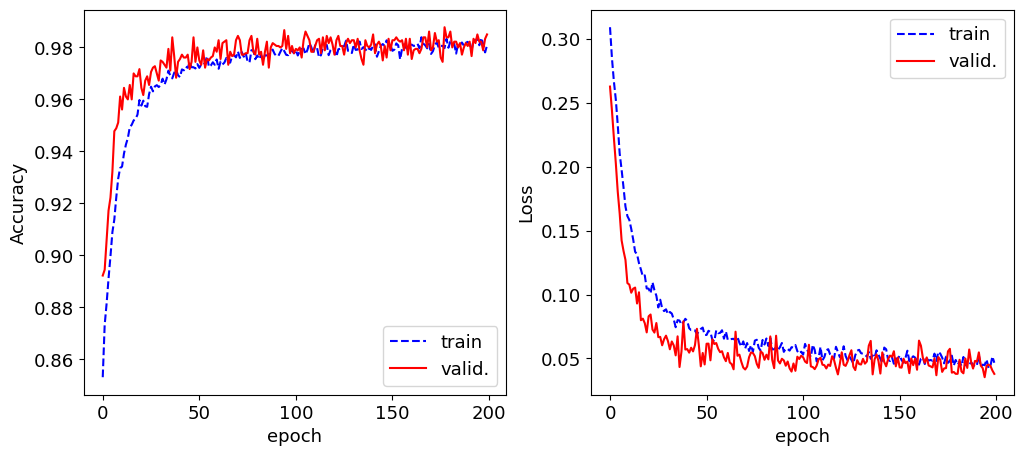

In [11]:
fig,AX=plt.subplots(1,2,figsize=(12,5.))
ax=AX[0]
ax.plot(fit.history['accuracy'],label="train",c="b",ls="--")
ax.plot(fit.history['val_accuracy'],label="valid.",c="r")
ax.set_xlabel('epoch')
ax.set_ylabel("Accuracy")
ax.legend()
ax=AX[1]
ax.plot(fit.history['loss'],label="train",c="b",ls="--")
ax.plot(fit.history['val_loss'],label="valid.",c="r")
ax.set_xlabel('epoch')
ax.set_ylabel("Loss")
ax.legend()

# Evaluation on the test set


In [12]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Final test loss: {test_loss:.4f}")
print(f"Final test accuracy: {test_acc:.4f}")

Final test loss: 0.0628
Final test accuracy: 0.9706


## Grid to show preditions

319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


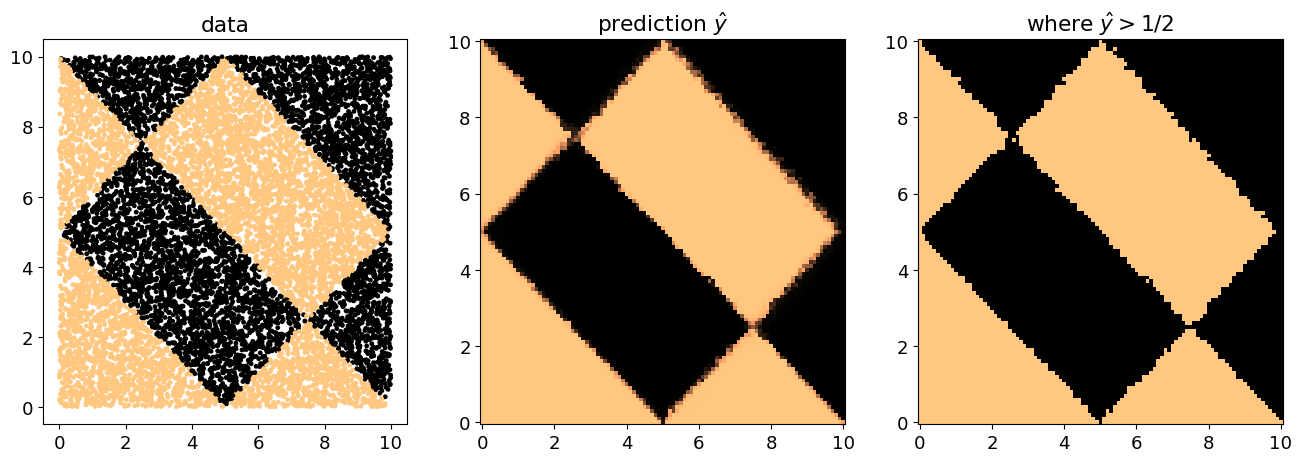

remember: these are 2 out of L=8 dimensions, of which L-2 contain random noise


In [13]:
dX = .1
X1 = np.arange(0,10+dX, dX)
LG = len(X1)
# 2D meshgrid
X, Y = np.meshgrid(X1, X1)
allXY = np.reshape((np.array((X,Y)).T),(LG**2,2))
#create synthetic inputs with L features for each grid point; initialized randomly in [0, B].
grid = np.random.rand(LG**2,L)*B
#replace first 2 features with the actual 2D coordinates
grid[:,:2] = allXY
#standardize using train-set mean/std before prediction
grid_r=Standardize(grid,x_train_mean,x_train_std)

pred = model.predict(grid_r)

fig,AX=plt.subplots(1,3,figsize=(16,5.))
ax=AX[0]
ax.scatter(x[:,0],x[:,1],c=y,s=6)
ax.set_title("data")
ax=AX[1]
ax.pcolormesh(X1,X1,pred.reshape((LG, LG)))
ax.set_title("prediction $\\hat y$")
ax=AX[2]
pred01=np.copy(pred)
pred01[pred>0.5]=1
pred01[pred<=0.5]=0
ax.pcolormesh(X1,X1,pred01.reshape((LG, LG)))
ax.set_title("where $\\hat y > 1/2$")
plt.show()
print(f"remember: these are 2 out of L={L} dimensions, of which L-2 contain random noise")

Type 3 is the dataset running in this notebook.

Overfitting -> reduce model capacity | dropout | early stopping

Underfitting -> increase model capacity | less dropout | tune optimizer (learning rate)

## Tuning Hyperparameters

In [14]:
import keras_tuner

In [15]:
def build_model(hp):
    model = Sequential()
    model.add(Dense(L,input_shape=(L,),activation='relu'))

    dropout_value = hp.Choice("dropout", [0.0, 0.1, 0.2])
    activation = hp.Choice("activation", ['relu', 'sigmoid'])

    model.add(Dense(20,activation=activation))
    model.add(Dropout(dropout_value))
    model.add(Dense(20,activation=activation))
    model.add(Dropout(dropout_value))
    model.add(Dense(20,activation=activation))
    model.add(Dropout(dropout_value))

    # final layer, sigmoid for probability interpretation
    model.add(Dense(1,activation='sigmoid'))
    nepoch=200

    learning_rate = hp.Choice("lr", [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1])

    model.compile(loss='binary_crossentropy',
              #optimizer=hp.Choiche("optimizer", ["adam", "rmsprop", "nadam"]),
              optimizer = keras.optimizers.Adam(learning_rate=learning_rate),
              metrics=['accuracy'])

    return model

* max_trials=max number of combination of hyperparameters tested

In [16]:
tuner = keras_tuner.RandomSearch(
    hypermodel=build_model,
    objective="val_accuracy",
    max_trials=15,
    executions_per_trial=2,
    #overwrite=True,
    directory="tuning_results",
    #project_name="tuning_results",
)

Reloading Tuner from tuning_results\untitled_project\tuner0.json


In [17]:
tuner.search_space_summary()

Search space summary
Default search space size: 3
dropout (Choice)
{'default': 0.0, 'conditions': [], 'values': [0.0, 0.1, 0.2], 'ordered': True}
activation (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'sigmoid'], 'ordered': False}
lr (Choice)
{'default': 1e-06, 'conditions': [], 'values': [1e-06, 1e-05, 0.0001, 0.001, 0.01, 0.1], 'ordered': True}


In [25]:
tuner.search(x_train, y_train, epochs=30, validation_data=(x_valid, y_valid))

Trial 15 Complete [00h 01m 10s]
val_accuracy: 0.948888897895813

Best val_accuracy So Far: 0.948888897895813
Total elapsed time: 00h 17m 55s


In [26]:
# print the 3 best models
tuner.results_summary(num_trials=3)

Results summary
Results in tuning_results\untitled_project
Showing 3 best trials
Objective(name="val_accuracy", direction="max")

Trial 14 summary
Hyperparameters:
dropout: 0.0
activation: sigmoid
lr: 0.01
Score: 0.948888897895813

Trial 08 summary
Hyperparameters:
dropout: 0.1
activation: sigmoid
lr: 0.01
Score: 0.9355555474758148

Trial 07 summary
Hyperparameters:
dropout: 0.2
activation: sigmoid
lr: 0.01
Score: 0.8480555713176727


## Permorming K-fold cross validation

We perform a k-fold cross validaiton on the models which have similar accuracy. In the cell below, we show for each trial of the tuner, the respective accuracy on the validation set and we select the models with similar accuracy

In [18]:
trials = tuner.oracle.trials
acc_dict = {str(i):trials[i].score for i in trials }
acc_dict = {k: v for k, v in sorted(acc_dict.items(), key=lambda item: item[1], reverse=True)}
acc_dict

{'14': 0.948888897895813,
 '08': 0.9355555474758148,
 '07': 0.8480555713176727,
 '02': 0.621111124753952,
 '03': 0.5586110949516296,
 '05': 0.547222226858139,
 '11': 0.539166659116745,
 '10': 0.5355555415153503,
 '06': 0.5255555808544159,
 '12': 0.5216666460037231,
 '00': 0.5213889181613922,
 '09': 0.5072222203016281,
 '13': 0.5000000149011612,
 '01': 0.4950000047683716,
 '04': 0.4888888895511627}

In [38]:
import numpy as np
from sklearn.model_selection import KFold

x_cv = np.concatenate((x_train, x_valid), axis=0)
y_cv = np.concatenate((y_train, y_valid), axis=0)

kf = KFold(n_splits=5, shuffle=True, random_state=12345)
selected = ['14', '08', '05', '11', '10']
final_accuracies = {}
for z in selected:
    print(f"\n--- Trial {z} ---")
    
    # get hyperparameters 
    hp = tuner.oracle.get_trial(z).hyperparameters
    
    fold_accuracies = []

    # Training on every fold
    for fold, (train_index, val_index) in enumerate(kf.split(x_cv)):
        x_train_fold, y_train_fold = x_cv[train_index], y_cv[train_index]
        x_val_fold, y_val_fold = x_cv[val_index], y_cv[val_index]
        
        model_fold = build_model(hp)
        
        model_fold.fit(x_train_fold, y_train_fold, epochs=30, batch_size=50, verbose=0)
        
        loss, acc = model_fold.evaluate(x_val_fold, y_val_fold, verbose=0)
        fold_accuracies.append(acc)
        
    # compute mean over the folds
    mean_acc = np.mean(fold_accuracies)

    final_accuracies[z] = mean_acc
    print("Final accuracy: ", mean_acc)



--- Trial 14 ---


c:\Users\CrisMattGiov\miniconda3\envs\in3050\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Final accuracy:  0.9607843160629272

--- Trial 08 ---
Final accuracy:  0.9632352948188782

--- Trial 05 ---
Final accuracy:  0.5381372451782227

--- Trial 11 ---
Final accuracy:  0.5186274528503418

--- Trial 10 ---
Final accuracy:  0.520784318447113


We can see that for trials 14 and 08, the accuracy are still compatible. Trials 05, 11, 10 report a lower overall accuracy, but they don't differ significatly. The best models are 14 and 08, with parameters

In [20]:
best_hp = tuner.get_best_hyperparameters(num_trials=2)

In [21]:
print("Trial 14 hp: ", best_hp[0].values)
print("Trial 8 hp: ", best_hp[1].values)

Trial 14 hp:  {'dropout': 0.0, 'activation': 'sigmoid', 'lr': 0.01}
Trial 8 hp:  {'dropout': 0.1, 'activation': 'sigmoid', 'lr': 0.01}


# Data augmentation

First we try to reduce the number N of samples, using the parameters of the best previous model, and see how the perform changes:

In [22]:
def making_plot(columns, train_values, val_values, title, xlabel, ylabel):
    x = np.arange(len(columns))
    width = 0.35

    plt.figure(figsize=(10, 6))
    plt.bar(x - width/2, train_values, width, color='blue', label='Train')
    plt.bar(x + width/2, val_values, width, color='red', label='Validation')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.ylim(max(0, min(min(train_values), min(val_values)) - 0.05), 1)
    plt.xticks(x, columns, rotation=45)
    plt.legend()
    plt.grid()
    plt.show()

f=0.1 | Train: 840, Valid: 180, Test: 180
f=0.2 | Train: 1680, Valid: 360, Test: 360
f=0.5 | Train: 4200, Valid: 900, Test: 900
f=0.8 | Train: 6720, Valid: 1440, Test: 1440
f=1 | Train: 8400, Valid: 1800, Test: 1800


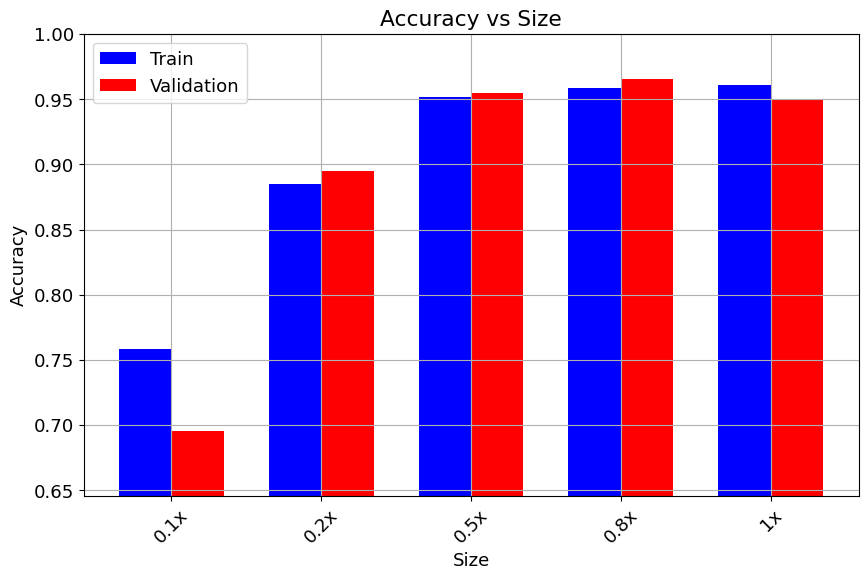

In [23]:
hype = best_hp[0]
result = []
reductions = [0.1, 0.2, 0.5, 0.8, 1]
N_runs = 5  # average over multiple runs to stabilize the accuracy

for f in reductions:
    N_r = int(f * len(x))
    x_r = x[:N_r]
    y_r = y[:N_r]
    N_train_r = int(perc_train * N_r)
    N_valid_r = int(perc_valid * N_r)
    N_test_r = int(perc_test * N_r)
    
    x_r_mean = np.mean(x_r)
    x_r_std = np.std(x_r)
    x_r = Standardize(x_r, x_r_mean, x_r_std)
    
    (x_train, y_train) = (x_r[:N_train_r], y_r[:N_train_r])
    (x_valid, y_valid) = (x_r[N_train_r:N_train_r+N_valid_r], y_r[N_train_r:N_train_r+N_valid_r])
    (x_test,  y_test)  = (x_r[N_train_r+N_valid_r:], y_r[N_train_r+N_valid_r:])
    
    print(f"f={f} | Train: {len(x_train)}, Valid: {len(x_valid)}, Test: {len(x_test)}")
    
    # fix batch size for small datasets
    effective_batch = min(50, len(x_train))
    
    accs_train = []
    accs_val = []
    for _ in range(N_runs):
        model = build_model(hype)
        hist = model.fit(x_train, y_train, epochs=30,
                         batch_size=effective_batch, verbose=0,
                         validation_data=(x_valid, y_valid))
        accs_train.append(hist.history['accuracy'][-1])
        accs_val.append(hist.history['val_accuracy'][-1])
    
    result += [[f, np.mean(accs_train), np.mean(accs_val)]]

result = np.array(result)
making_plot([str(f) + "x" for f in reductions], result[:, 1], result[:, 2],
            title="Accuracy vs Size", xlabel="Size", ylabel="Accuracy")

As we can see from the plot, the accuracy decreases with the size of the sample. This is expected, as we have more data with which to fit the model.

Now we perfom data augmentation adding some noise:

In [24]:
def augment_data(x_train, y_train, noise_std=0.05, n_augments=2):
    ''' Augmented data 
       Add noise sampled from a Gaussian distribution with a set std
       n_augments is the size of the new data (as multiple of the original dataset size)
    '''
    x_aug, y_aug = [x_train], [y_train]
    
    for _ in range(n_augments):
        noise = np.random.normal(0, noise_std, x_train.shape)
        x_aug.append(x_train + noise)
        y_aug.append(y_train)
    
    return np.concatenate(x_aug), np.concatenate(y_aug)

In [27]:
model = build_model(hype)

x_a_mean = np.mean(x)
x_a_std  = np.std(x)
x_a      = Standardize(x, x_a_mean, x_a_std)

(x_train, y_train) = (x_a[:N_train], y[:N_train])
(x_valid, y_valid) = (x_a[N_train:N_train+N_valid], y[N_train:N_train+N_valid])
(x_test,  y_test)  = (x_a[N_train+N_valid:], y[N_train+N_valid:])

x_train_aug, y_train_aug = augment_data(x_train, y_train, noise_std=0.05, n_augments=2) # here we can set the noise of the augmented data
print(f"Train: {len(x_train)}, Train_aug: {len(x_train_aug)}, Valid: {len(x_valid)}, Test: {len(x_test)}")

fit = model.fit(x_train_aug, y_train_aug,
                epochs=nepoch, batch_size=50,
                validation_data=(x_valid, y_valid),
                verbose=0)



Train: 8400, Train_aug: 25200, Valid: 1800, Test: 1800


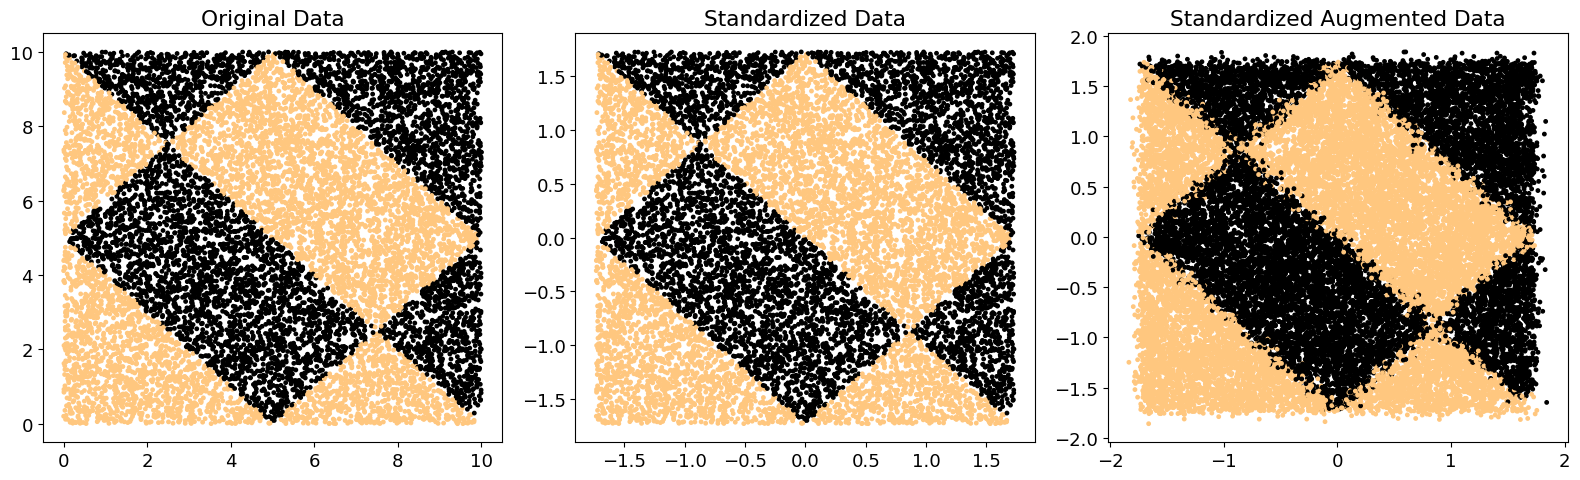

In [28]:
fig, AX = plt.subplots(1, 3, figsize=(16, 5.))

ax = AX[0]
ax.scatter(x[:, 0], x[:, 1], c=y, s=6)
ax.set_title("Original Data")

ax = AX[1]
ax.scatter(x_a[:, 0], x_a[:, 1], c=y, s=6)
ax.set_title("Standardized Data")

ax = AX[2]
ax.scatter(x_train_aug[:, 0], x_train_aug[:, 1], c=y_train_aug, s=6)
ax.set_title("Standardized Augmented Data")

plt.tight_layout()
plt.show()

In [29]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Final test loss: {test_loss:.4f}")
print(f"Final test accuracy: {test_acc:.4f}")

Final test loss: 0.0694
Final test accuracy: 0.9733


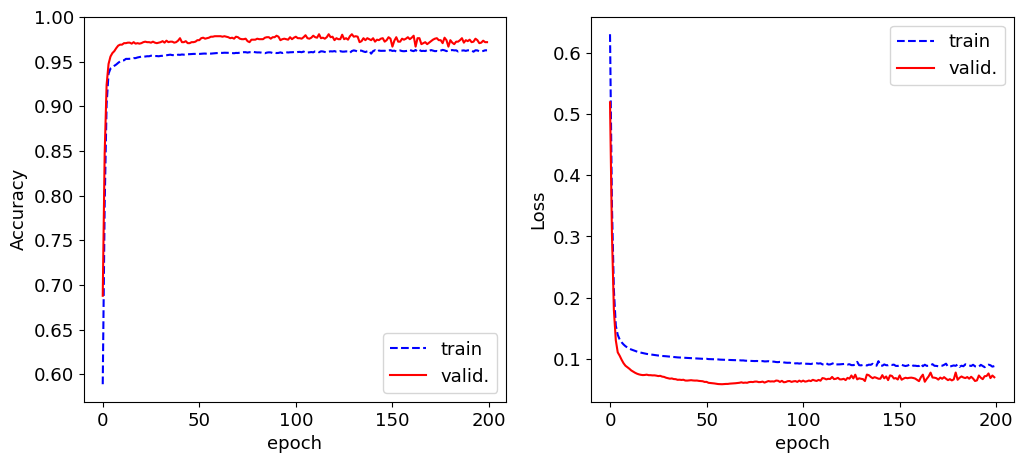

In [30]:
fig,AX=plt.subplots(1,2,figsize=(12,5.))
ax=AX[0]
ax.plot(fit.history['accuracy'],label="train",c="b",ls="--")
ax.plot(fit.history['val_accuracy'],label="valid.",c="r")
ax.set_xlabel('epoch')
ax.set_ylabel("Accuracy")
ax.legend()
ax=AX[1]
ax.plot(fit.history['loss'],label="train",c="b",ls="--")
ax.plot(fit.history['val_loss'],label="valid.",c="r")
ax.set_xlabel('epoch')
ax.set_ylabel("Loss")
ax.legend()

Including augmented data in the training set means we reach a better accuracy with fewer epochs compared to the baseline. Both accuracy and loss are also more stable, i.e. their fluctuations with respect to the number of epochs are smaller than in the original case.